In [35]:
import cv2
import numpy as np
import matplotlib as plt
import matplotlib.pyplot as plt

In [36]:
image = cv2.imread('Jupiter.jpg')
image_hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)  

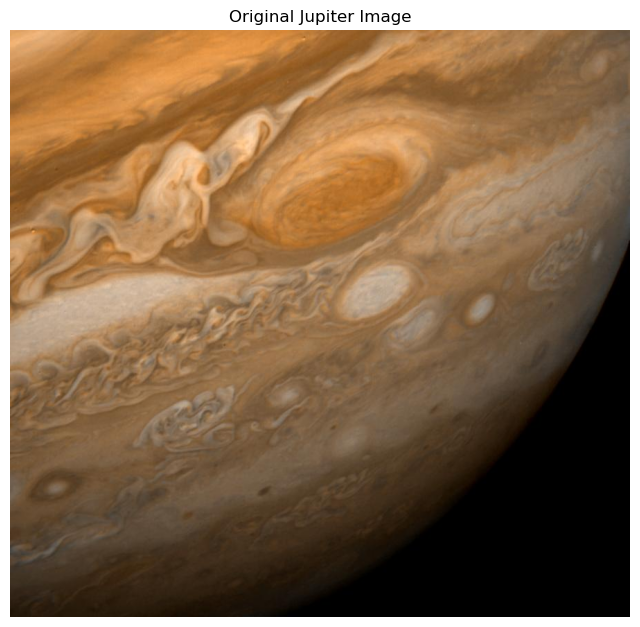

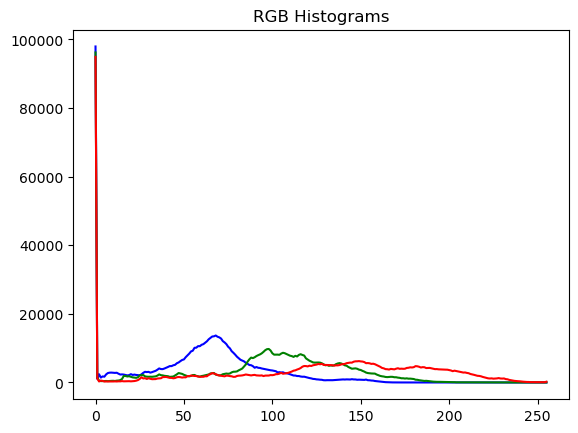

In [37]:
plt.figure(figsize=(8,8))

plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB)) #we convert from BGR to RGB coz matplotlib cannot read in terms of BGR

plt.title("Original Jupiter Image")

plt.axis('off')

plt.show()

#HISTOGRAM

b,g,r = cv2.split(image)

for channel,color in zip([b,g,r],['b','g','r']):

    hist = cv2.calcHist([channel],[0],None,[256],[0,256])
    plt.plot(hist,color=color)

plt.title("RGB Histograms")
plt.show()

In [43]:
h,s,v = cv2.split(image_hsv)
v_eq = cv2.equalizeHist(v)

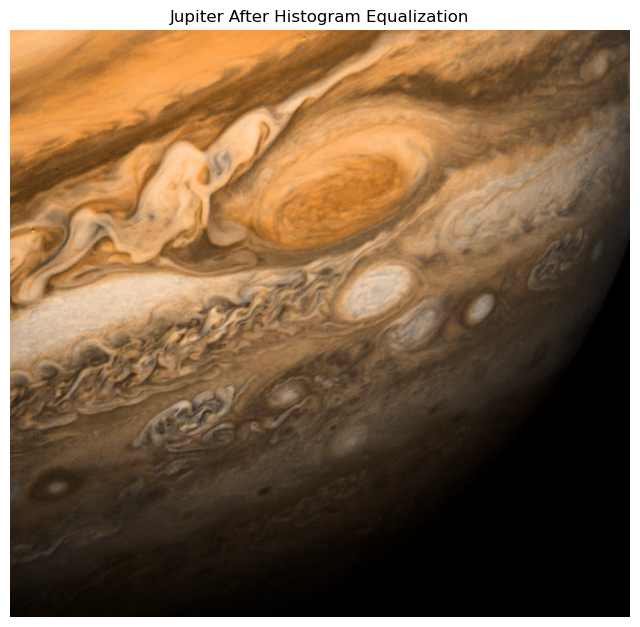

In [44]:
plt.figure(figsize=(8,8))

plt.imshow(jupiter_eq)

plt.title("Jupiter After Histogram Equalization")

plt.axis('off')

plt.show()

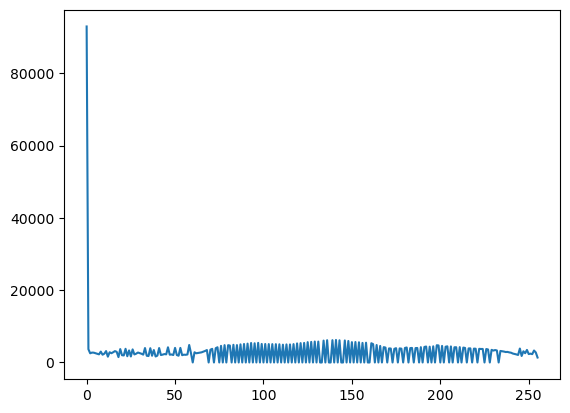

In [40]:
hsv_eq = cv2.merge((h,s,v_eq))
jupiter_eq = cv2.cvtColor(
    hsv_eq,
    cv2.COLOR_HSV2RGB
)
hist_v_eq = cv2.calcHist(
    [v_eq],
    [0],
    None,
    [256],
    [0,256]
)

plt.plot(hist_v_eq)
plt.show()

In [41]:
#CLAHE

In [45]:
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))

# Assuming you have an HSV image, split it into channels
h, s, v = cv2.split(image_hsv)  # You need to define hsv_image first

# Apply CLAHE to the V channel
v_clahe = clahe.apply(v)
hsv_clahe = cv2.merge((h,s,v_clahe))

jupiter_clahe = cv2.cvtColor(
    hsv_clahe,
    cv2.COLOR_HSV2RGB
)

edges = cv2.Canny(hsv_clahe,100,200) #CANNY FILTER
edges = cv2.Canny(image,100,200) #CANNY FILTER

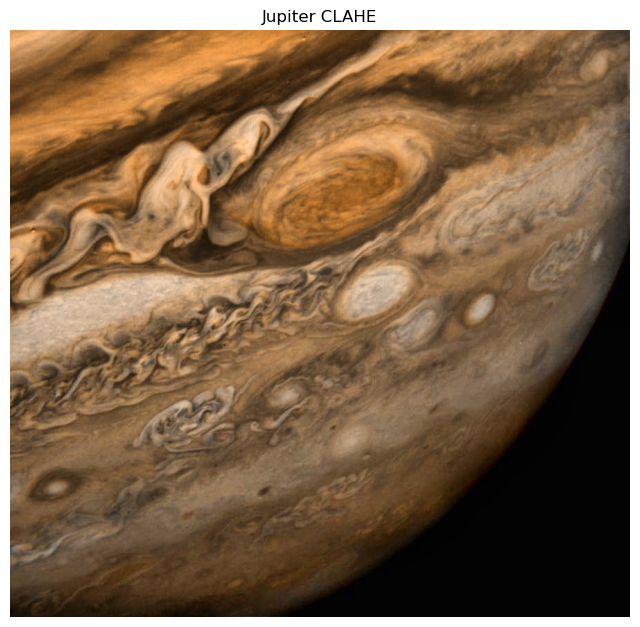

In [46]:
plt.figure(figsize=(8,8))
plt.imshow(jupiter_clahe)
plt.title("Jupiter CLAHE")
plt.axis('off')
plt.show()

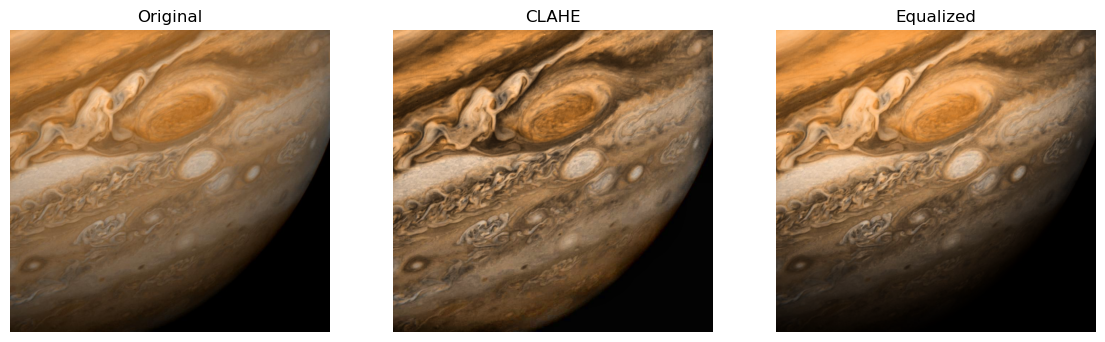

In [47]:
fig,ax = plt.subplots(1,3, figsize=(14,6))

ax[0].imshow(
    cv2.cvtColor(image,cv2.COLOR_BGR2RGB)
)
ax[0].set_title("Original")

ax[1].imshow(cv2.cvtColor(hsv_clahe,cv2.COLOR_HSV2RGB))  # Fixed: removed extra '[' bracket
ax[1].set_title("CLAHE")
    
ax[2].imshow(jupiter_eq)
ax[2].set_title("Equalized")
jupiter_clahe

for a in ax:
    a.axis('off')

plt.show()

In [51]:
import cv2
import numpy as np

# First, you need to define v_clahe - here's an example of how it's typically created:
# Load an image (replace 'your_image.jpg' with your actual image path)
image = cv2.imread('Jupiter.jpg')

# Convert to grayscale if the image is colored
gray = cv2.cvtColor(image_hsv, cv2.COLOR_BGR2GRAY)

# Extract V channel from HSV or use grayscale image
hsv = cv2.cvtColor(image_hsv, cv2.COLOR_BGR2HSV)
v_channel = hsv[:, :, 2]  # V channel from HSV

# Apply CLAHE (Contrast Limited Adaptive Histogram Equalization) to V channel
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
v_clahe = clahe.apply(v_channel)  # Now v_clahe is defined

# Now the original code will work
ret, otsu_v = cv2.threshold(
    v_clahe,  # v_clahe is now properly defined
    0,
    255,
    cv2.THRESH_BINARY + cv2.THRESH_OTSU
)

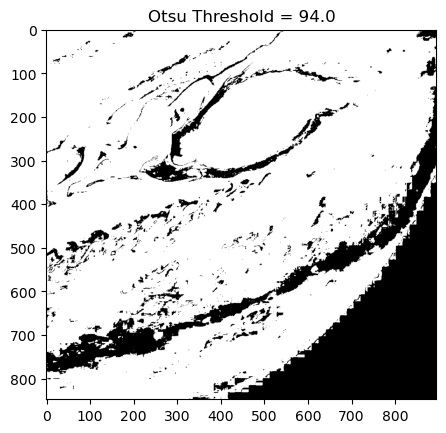

In [53]:
plt.imshow(otsu_v,cmap='gray')
plt.title(f"Otsu Threshold = {ret}")
plt.show()

In [54]:
contours, hierarchy = cv2.findContours(
    otsu_v,
    cv2.RETR_EXTERNAL,
    cv2.CHAIN_APPROX_SIMPLE
)

In [59]:
filtered = []

for c in contours:
    area = cv2.contourArea(c)

    if area > 500:
        filtered.append(c)

print("Contours:", len(filtered))

area = cv2.contourArea(c)

perimeter = cv2.arcLength(c, True)

diameter = np.sqrt(4*area/np.pi)

Contours: 2


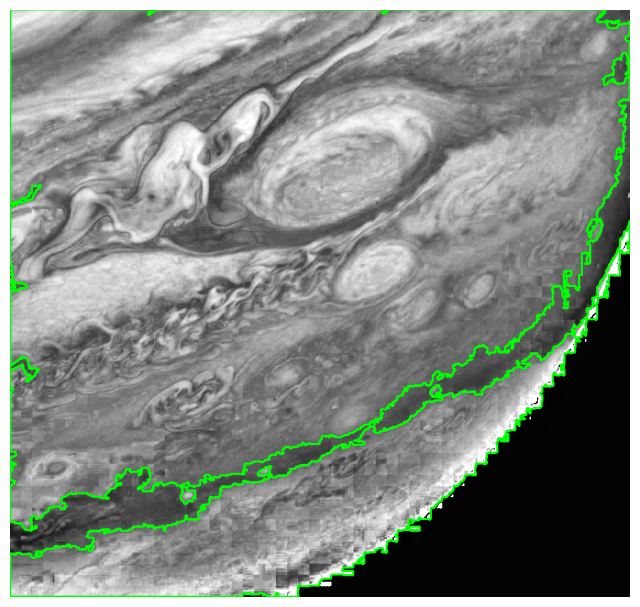

In [60]:
img_draw = cv2.cvtColor(v_clahe, cv2.COLOR_GRAY2BGR)

cv2.drawContours(
    img_draw,
    filtered,
    -1,
    (0,255,0),
    2
)

plt.figure(figsize=(8,8))
plt.imshow(cv2.cvtColor(img_draw, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()